In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.autograd import Variable
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import MinMaxScaler
import os
#os.chdir("D:/Training/Academy/ML(Python)/Datasets")

In [2]:
test_size = 24
seq_length = 10 #time steps should be less than test size

In [3]:
dataset_ts = pd.read_csv("D:/Training/Academy/ML_Python/Datasets/AirPassengers.csv")
dataset_train = dataset_ts.iloc[:-test_size,:10].values
dataset_test = dataset_ts.iloc[-test_size:,:10].values
training_set = dataset_train[:,1:2]
testing_set = dataset_test[:,1:2]
sc = MinMaxScaler()
training_set_scaled = sc.fit_transform(training_set)
testing_set_scaled = sc.transform(testing_set)
training_set_scaled.shape, testing_set_scaled.shape

((120, 1), (24, 1))

In [4]:
def sliding_windows(data, seq_length):
    x = []
    y = []

    for i in range(len(data)-seq_length-1):
        _x = data[i:(i+seq_length)]
        _y = data[i+seq_length]
        x.append(_x)
        y.append(_y)

    return np.array(x),np.array(y)

In [5]:
X_train, y_train = sliding_windows(training_set_scaled, seq_length)
X_test, y_test = sliding_windows(testing_set_scaled, seq_length)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((109, 10, 1), (109, 1), (13, 10, 1), (13, 1))

In [6]:
trainX = Variable(torch.Tensor(np.array(X_train)))
trainY = Variable(torch.Tensor(np.array(y_train)))

testX = Variable(torch.Tensor(np.array(X_test)))
testY = Variable(torch.Tensor(np.array(y_test)))
trainX.shape, trainY.shape, testX.shape, testY.shape

(torch.Size([109, 10, 1]),
 torch.Size([109, 1]),
 torch.Size([13, 10, 1]),
 torch.Size([13, 1]))

In [7]:
class GRU(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super(GRU, self).__init__()
        self.num_classes = num_classes
        self.num_layers = num_layers
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size=input_size, hidden_size=hidden_size,
                            num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        h_0 = Variable(torch.zeros( self.num_layers, x.size(0), self.hidden_size))
        # Correctly unpack output and hidden state
        ula, h_out_all_layers = self.gru(x, h_0)
        # h_out_all_layers has shape (num_layers * num_directions, batch, hidden_size)
        # For a single layer GRU, we take the last hidden state and reshape for the FC layer
        h_out = h_out_all_layers.view(-1, self.hidden_size)
        out = self.fc(h_out)

        return out

In [8]:
num_epochs, learning_rate = 2000, 0.01
input_size, hidden_size, num_layers, num_classes = 1, 2, 1, 1
gru = GRU(num_classes, input_size, hidden_size, num_layers)
gru(trainX)

tensor([[0.1568],
        [0.1609],
        [0.1608],
        [0.1614],
        [0.1599],
        [0.1568],
        [0.1562],
        [0.1574],
        [0.1541],
        [0.1491],
        [0.1465],
        [0.1469],
        [0.1509],
        [0.1559],
        [0.1544],
        [0.1530],
        [0.1516],
        [0.1464],
        [0.1462],
        [0.1445],
        [0.1426],
        [0.1383],
        [0.1361],
        [0.1371],
        [0.1409],
        [0.1453],
        [0.1445],
        [0.1435],
        [0.1416],
        [0.1387],
        [0.1391],
        [0.1388],
        [0.1333],
        [0.1288],
        [0.1246],
        [0.1272],
        [0.1310],
        [0.1358],
        [0.1349],
        [0.1343],
        [0.1341],
        [0.1280],
        [0.1252],
        [0.1246],
        [0.1221],
        [0.1176],
        [0.1142],
        [0.1174],
        [0.1226],
        [0.1298],
        [0.1304],
        [0.1306],
        [0.1333],
        [0.1275],
        [0.1261],
        [0

In [9]:
num_epochs, learning_rate = 2000, 0.01
input_size, hidden_size, num_layers, num_classes = 1, 2, 1, 1
gru = GRU(num_classes, input_size, hidden_size, num_layers)
criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(gru.parameters(), lr=learning_rate)
for epoch in range(num_epochs):
    outputs = gru(trainX)
    optimizer.zero_grad()
    loss = criterion(outputs, trainY)
    loss.backward()
    optimizer.step()
    if epoch % 100 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, loss.item()))

Epoch: 0, loss: 0.20097
Epoch: 100, loss: 0.00793
Epoch: 200, loss: 0.00643
Epoch: 300, loss: 0.00583
Epoch: 400, loss: 0.00533
Epoch: 500, loss: 0.00492
Epoch: 600, loss: 0.00461
Epoch: 700, loss: 0.00439
Epoch: 800, loss: 0.00425
Epoch: 900, loss: 0.00419
Epoch: 1000, loss: 0.00416
Epoch: 1100, loss: 0.00414
Epoch: 1200, loss: 0.00412
Epoch: 1300, loss: 0.00411
Epoch: 1400, loss: 0.00409
Epoch: 1500, loss: 0.00407
Epoch: 1600, loss: 0.00405
Epoch: 1700, loss: 0.00403
Epoch: 1800, loss: 0.00402
Epoch: 1900, loss: 0.00401


In [10]:
h_0 = Variable(torch.zeros( 1, 109, 2))
h_0

tensor([[[0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0., 0.],
         [0.

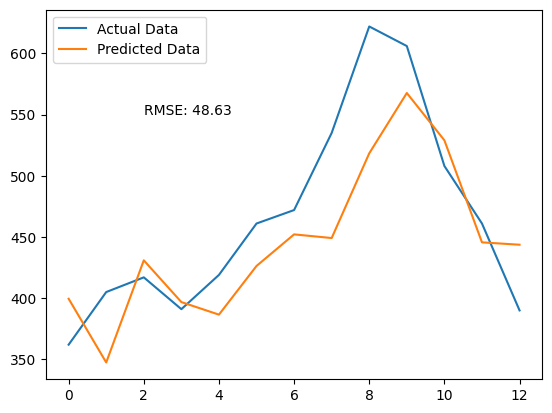

In [13]:
gru.eval()
test_predict = gru(testX)
data_predict = test_predict.data.numpy()
dataY_plot = testY.data.numpy()
data_predict = sc.inverse_transform(data_predict)
dataY_plot = sc.inverse_transform(dataY_plot)
plt.plot(dataY_plot, label='Actual Data')
plt.plot(data_predict, label='Predicted Data')
rmse = root_mean_squared_error(dataY_plot, data_predict)
plt.legend()
plt.text(2,550, "RMSE: %.2f" % rmse)
plt.show()